# TP1 - Parte 2: Histogramas

**Consigna:**
1. Para las imágenes `img1_tp.png` y `img2_tp.png` leerlas con OpenCV en escala de grises y visualizarlas.
2. Elegir el número de bins que se crea conveniente y graficar su histograma, comparar los histogramas entre sí. Explicar lo que se observa, y si sirve tomar los histogramas como *features* para un modelo de clasificación/detección.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR = Path("imagenes")

img1 = cv2.imread(str(IMG_DIR / "img1_tp.png"), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(str(IMG_DIR / "img2_tp.png"), cv2.IMREAD_GRAYSCALE)

print("img1_tp:", img1.shape, img1.dtype)
print("img2_tp:", img2.shape, img2.dtype)

img1_tp: (288, 287) uint8
img2_tp: (288, 287) uint8


## Visualización en escala de grises

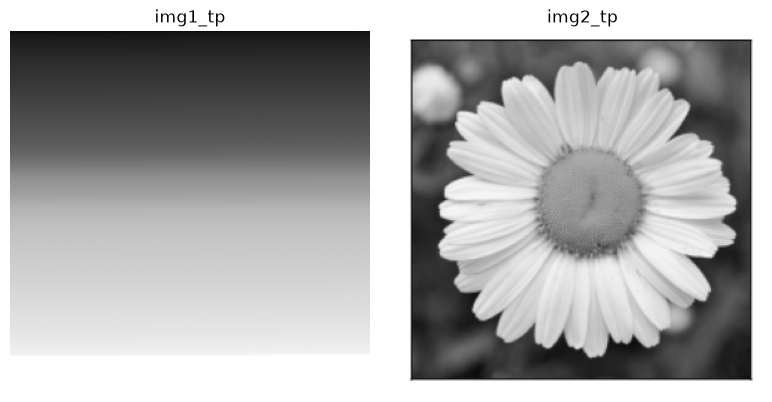

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("img1_tp")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("img2_tp")
axes[1].axis("off")
plt.tight_layout()

## Elección del número de bins

Una imagen de 8 bits tiene 256 niveles de gris posibles. Con **256 bins** el histograma es exacto (un bin = un nivel de intensidad), pero puede verse ruidoso si la imagen tiene pocos píxeles o poca variedad tonal. Con menos bins (ej. **32**) se agrupan niveles vecinos, suavizando el histograma y facilitando ver la forma general de la distribución a costa de perder resolución fina.

Ambas imágenes tienen ~82000 píxeles (288x287), suficiente para que 256 bins no sea puro ruido. Se comparan igual ambas resoluciones para justificar la elección.

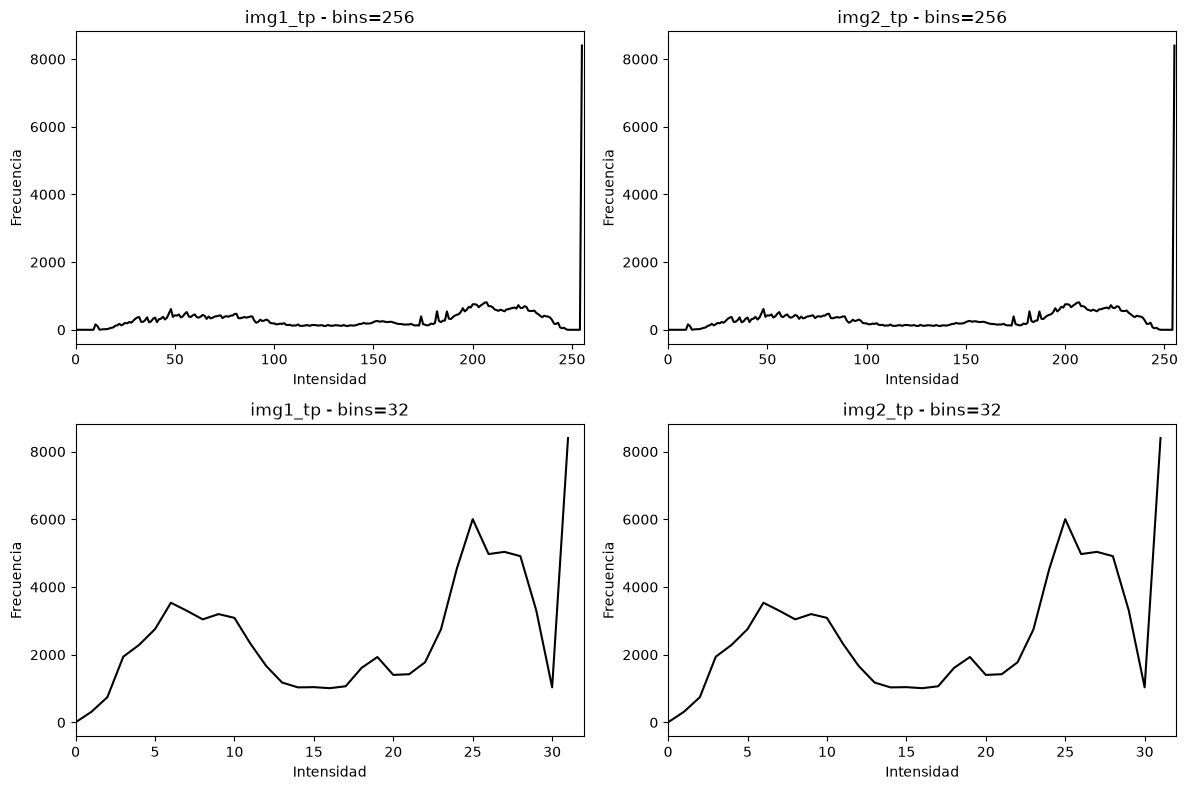

In [3]:
def graficar_histogramas(imagenes, nombres, bins, ax_row):
    for ax, img, nombre in zip(ax_row, imagenes, nombres):
        hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
        ax.plot(hist, color="black")
        ax.set_title(f"{nombre} - bins={bins}")
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Frecuencia")
        ax.set_xlim([0, bins])


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
graficar_histogramas([img1, img2], ["img1_tp", "img2_tp"], bins=256, ax_row=axes[0])
graficar_histogramas([img1, img2], ["img1_tp", "img2_tp"], bins=32, ax_row=axes[1])
plt.tight_layout()

## Comparación directa (superpuestos)

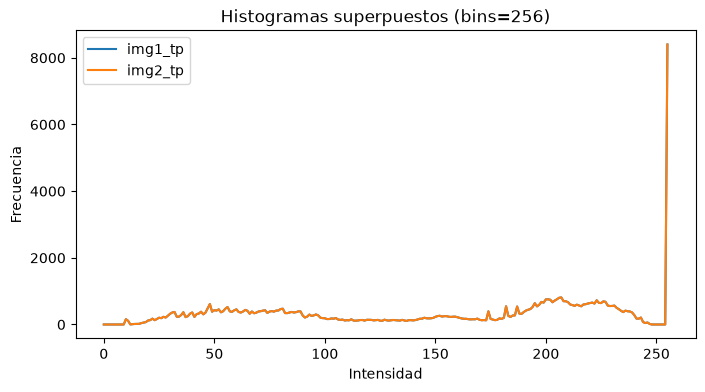

Correlación entre histogramas: 1.0000


In [4]:
bins = 256
hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist1, label="img1_tp", color="tab:blue")
plt.plot(hist2, label="img2_tp", color="tab:orange")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.legend()
plt.title(f"Histogramas superpuestos (bins={bins})")
plt.show()

# Métrica simple de comparación entre distribuciones
correlacion = cv2.compareHist(hist1.astype(np.float32), hist2.astype(np.float32), cv2.HISTCMP_CORREL)
print(f"Correlación entre histogramas: {correlacion:.4f}")

## ¿Por qué los histogramas son idénticos?

Las curvas se ven exactamente iguales. Antes de sacar conclusiones, verificamos si las imágenes son la misma o no, y si comparten el mismo conjunto de valores de píxel.

In [5]:
pixeles_identicos = np.array_equal(img1, img2)
misma_distribucion_de_valores = np.array_equal(np.sort(img1.flatten()), np.sort(img2.flatten()))

print("¿Son la misma imagen (mismos píxeles en las mismas posiciones)?", pixeles_identicos)
print("¿Tienen el mismo multiset de valores de gris (permutación espacial)?", misma_distribucion_de_valores)
print(f"media img1={img1.mean():.4f}  media img2={img2.mean():.4f}")
print(f"std   img1={img1.std():.4f}  std   img2={img2.std():.4f}")

¿Son la misma imagen (mismos píxeles en las mismas posiciones)? False
¿Tienen el mismo multiset de valores de gris (permutación espacial)? True
media img1=154.8136  media img2=154.8136
std   img1=75.3423  std   img2=75.3423


## Análisis

**Hallazgo clave:** `img1_tp` e `img2_tp` tienen histogramas **idénticos** (correlación = 1.0000, media y
desvío estándar iguales al bit). Sin embargo, `np.array_equal(img1, img2)` da `False`: son imágenes
distintas. Verificando el multiset de valores (`np.sort(img1.flatten()) == np.sort(img2.flatten())`), se
confirma que `img2_tp` es exactamente los mismos píxeles que `img1_tp`, **reordenados espacialmente**.

Esto es la demostración práctica de la limitación central del histograma como descriptor: es una
**estadística global e invariante al orden espacial de los píxeles**. Cuenta cuántos píxeles hay de cada
intensidad, pero no dónde están. Dos imágenes con contenido, formas y estructura completamente distintos
(por ejemplo, una foto reconocible vs. la misma foto con los píxeles mezclados aleatoriamente) pueden tener
el histograma perfectamente indistinguible.

**Respuesta a la consigna (¿sirve como feature para clasificación/detección?):**
No alcanza por sí solo. Un histograma de intensidades es útil como *feature auxiliar* (por ejemplo, para
capturar iluminación general, contraste o rango dinámico de la imagen), pero **es incapaz de capturar forma,
bordes, texturas o la posición relativa de los objetos** — que es justamente lo que necesita un clasificador o
detector para distinguir un objeto de otro. Cualquier modelo que dependiera únicamente de histogramas
confundiría imágenes estructuralmente distintas con estadísticas de intensidad iguales, como el par
`img1_tp`/`img2_tp` de este mismo TP. En la práctica, el histograma se combina con descriptores que sí
preservan información espacial (bordes, gradientes, texturas, keypoints) en vez de usarse solo.